In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import make_column_selector,make_column_transformer
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


Loading data...
Data Loaded: (400, 3)
Preprocessing Data

Checking Null Values:
 Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Checking Duplicate Values:
 33

Removing Duplicate Values:
      Age  EstimatedSalary  Purchased
0     19            19000          0
1     35            20000          0
2     26            43000          0
3     27            57000          0
4     19            76000          0
..   ...              ...        ...
395   46            41000          1
396   51            23000          1
397   50            20000          1
398   36            33000          0
399   49            36000          1

[367 rows x 3 columns]

Checking Duplicate Values Again:
 33
Preprocessing Complete
Splitting
Splitting Done
Loading data...
Data Loaded: (400, 3)
Preprocessing Data

Checking Null Values:
 Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Checking Duplicate Values:
 33

Removing Duplicate Values:
      Age  

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Completed

Evaluating model...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Test Accuracy: 0.9417


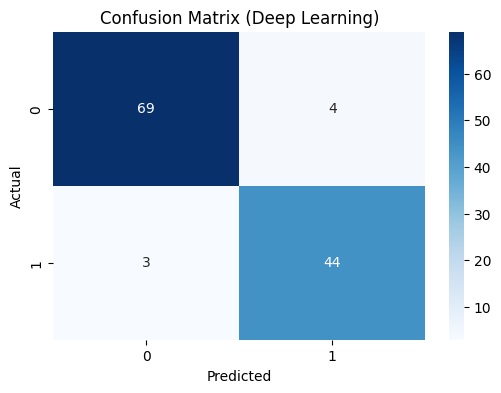

In [55]:
class SocialNetworkAdsModel:
  def __init__(self,file_path,test_size=0.3,random_state = 42):
    self.file_path = file_path
    self.test_size = test_size
    self.random_state = random_state
    self.df = None

    self.X = None
    self.y = None

    self.X_train = None
    self.X_test = None
    self.y_train = None
    self.y_test = None

    self.pipeline = None


  def load_data(self):
            print("Loading data...")
            self.df = pd.read_csv(self.file_path)
            print(f"Data Loaded: {self.df.shape}")


  def preprocess_and_split(self):
        self.load_data()

        print("Preprocessing Data")
        print("\nChecking Null Values:\n", self.df.isnull().sum())
        print("\nChecking Duplicate Values:\n",self.df.duplicated().sum())
        print("\nRemoving Duplicate Values:\n",self.df.drop_duplicates())
        print("\nChecking Duplicate Values Again:\n",self.df.duplicated().sum())
        print("Preprocessing Complete")

        print("Splitting")
        X = self.df.drop(columns="Purchased")
        y = self.df["Purchased"]

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )
        print("Splitting Done")


  def build_pipeline(self):
        self.preprocess_and_split()
        print("Building Pipeline")
        cat_selector = make_column_selector(dtype_include=[object])
        num_selector = make_column_selector(dtype_include=[np.number])

        self.transformer = make_column_transformer(
            (OneHotEncoder(handle_unknown='ignore'), cat_selector),
            (StandardScaler(), num_selector),
            remainder="passthrough"
        )
        self.X_train = self.transformer.fit_transform(self.X_train)
        self.X_test = self.transformer.transform(self.X_test)
        print("Pipeline Complete")

  def build_dl_model(self):
        self.build_pipeline()
        print("Building Deep Learning Model...")
        input_dim = self.X_train.shape[1]

        self.model = tf.keras.Sequential([
            tf.keras.layers.Dense(units=12, activation='relu',
                                  input_shape=(input_dim,)),
            tf.keras.layers.Dense(units=8, activation='relu'),
            tf.keras.layers.Dense(units=1, activation='sigmoid')
        ])

        self.model.compile(optimizer='adam', loss='binary_crossentropy',
                           metrics=['accuracy'])

  def train(self, epochs=50):
        self.preprocess_and_split()
        self.build_dl_model()
        print("Starting Training...")
        self.model.fit(self.X_train, self.y_train, epochs=epochs,
                       batch_size=10, verbose=0)
        print("Training Completed")

  def evaluate(self):
        self.train()
        print("\nEvaluating model...")

        # Get predictions (DL returns probabilities)
        y_pred_prob = self.model.predict(self.X_test)
        y_pred = (y_pred_prob > 0.5).astype(int)

        accuracy = accuracy_score(self.y_test, y_pred)
        print(f"Test Accuracy: {accuracy:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(self.y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
        plt.title("Confusion Matrix (Deep Learning)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()


if __name__ == "__main__":
    DATA_PATH = "Social_Network_Ads.csv"
    dl_classifier = SocialNetworkAdsModel(DATA_PATH)
    dl_classifier.evaluate()

